In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_val.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_train.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/zero-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_test.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal375.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal341.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal374.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal383.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-class

## **Import the dependancies**

In [ ]:
import os
import torch
import torchvision
from torch.utils.data import random_split
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

### see the labels in the dataset

In [ ]:
data_dir = '/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification'

classes = os.listdir(data_dir)
classes

['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']

### Transformation
   * it is like image augmintation with tf but it is neccessary for pytorch

In [ ]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

transformation = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
dataset = ImageFolder(data_dir, transform = transformation)

In [ ]:
len(dataset)

2527

### Create a helper function to show some images and its labels

In [ ]:
import matplotlib.pyplot as plt

def show_image(img , label):
    print(f"label : {dataset.classes[label]}")
    plt.imshow(img.permute(1,2,0))

label : cardboard


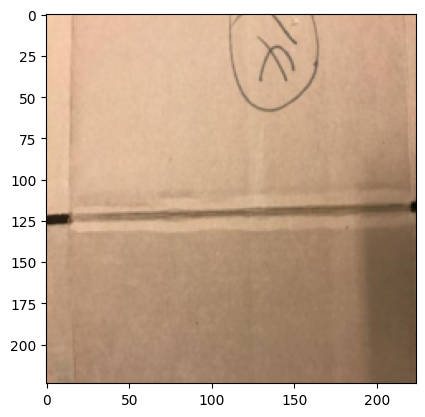

In [ ]:
img , label = dataset[0]
show_image(img,label)

## Loading and splitting data

In [ ]:
random_seed = 42
torch.manual_seed(random_seed)

### splitting tha data to train , validation , test

In [ ]:
train_data , val_data , test_data = random_split(dataset , [1593, 176, 758])
len(train_data) , len(val_data) , len(test_data)

(1593, 176, 758)

In [ ]:
from torch.utils.data.dataloader import DataLoader
batch_size = 32

In [ ]:
train_dl = DataLoader(train_data, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_dl = DataLoader(val_data, batch_size * 2, num_workers=4, pin_memory = True)

## Model Base

In [ ]:
def accuracy(output , labels):
    _ , preds = torch.max(output,dim=1)
    acc = torch.tensor( torch.sum(preds == labels).item() / len(labels) )
    return acc

In [ ]:
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

### We'll be using ResNet50 for classifying images:

In [ ]:

class ResNet50(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = models.resnet50(pretrained = True) # ued a pretrained model
        num_ftrs = self.network.fc.in_features # replace last layer with my numer of feature
        self.network.fc = nn.Linear(num_ftrs , len(dataset.classes))

    def forward(self , xb):
        return self.network(xb)

In [ ]:
model = ResNet50()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]



### Porting to GPU:

* GPUs tend to perform faster calculations than CPU. Let's take this advantage and use GPU for computation:


In [ ]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [ ]:
device = get_default_device()
device

device(type='cpu')

In [ ]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet50(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
         

## Training the model
* function for fitting the model

In [ ]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
model = to_device(ResNet50() , device)

In [ ]:
evaluate(model , val_dl)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'val_loss': 1.7745388746261597, 'val_acc': 0.2100694328546524}

In [ ]:
num_of_epochs = 8
optimization_func = torch.optim.Adam
lr = 5.5e-5

history = fit(num_of_epochs,
              lr,
              model,
              train_dl,
              val_dl,
              optimization_func)

Epoch 1: train_loss: 0.8528, val_loss: 0.4016, val_acc: 0.8889
Epoch 2: train_loss: 0.1904, val_loss: 0.2236, val_acc: 0.9514
Epoch 3: train_loss: 0.0686, val_loss: 0.1803, val_acc: 0.9497
Epoch 4: train_loss: 0.0275, val_loss: 0.1854, val_acc: 0.9514
Epoch 5: train_loss: 0.0247, val_loss: 0.1993, val_acc: 0.9271
Epoch 6: train_loss: 0.0192, val_loss: 0.2352, val_acc: 0.9201
Epoch 7: train_loss: 0.0152, val_loss: 0.1977, val_acc: 0.9392
Epoch 8: train_loss: 0.0224, val_loss: 0.2578, val_acc: 0.9149


In [ ]:
def plot_accuracy(history):
    accuracy = [x['val_acc'] for x in history]
    plt.plot(accuracy)
    plt.xlabel('No. epochs')
    plt.ylabel('accuracy')
    plt.title('model accuracy')
    plt.show()

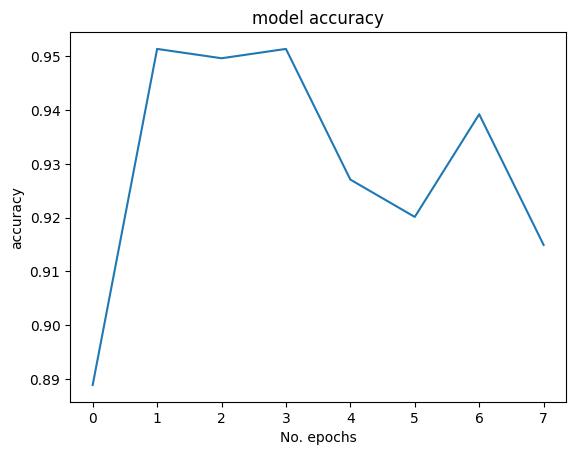

In [ ]:
plot_accuracy(history)

In [ ]:
def plot_loss(history):
    train_loss = [x.get('train_loss') for x in history]
    val_loss = [x.get('val_loss') for x in history]
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.xlabel('No. epochs')
    plt.ylabel('accuracy')
    plt.title('model Loss')
    plt.legend(['training' , 'validation'] , loc="upper left")
    plt.show()

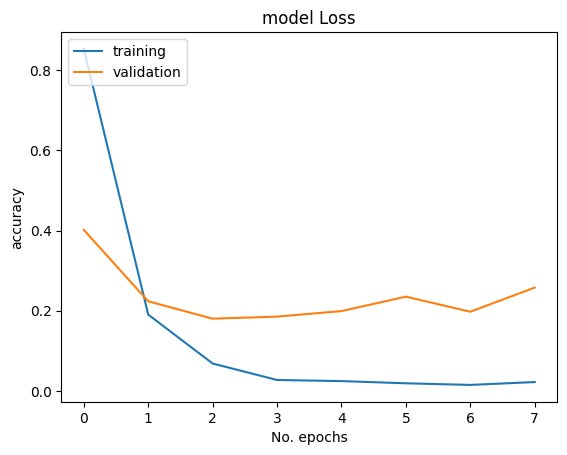

In [ ]:
plot_loss(history)

## Visualize a prediction

In [ ]:
def predict_img(img,model):
    #convert image to a batch of 1
    xb = to_device(img.unsqueeze(0),device)

    # get a prediction from model
    yb = model(xb)

    # get the index with heighest Probability
    probs , pred = torch.max(yb,dim = 1)

    # return the class label
    return dataset.classes[pred[0].item()]

label is : paper , and the prediction is : paper


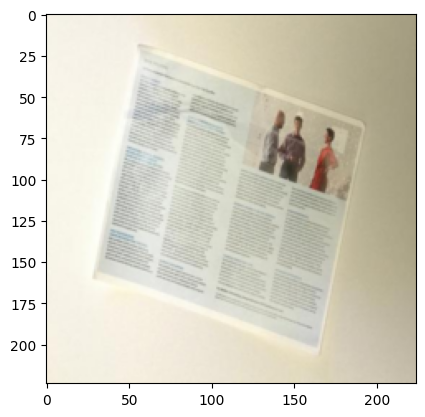

In [ ]:
# i tried indecies 7, 20 , 520 and model predicted them well.
img_index = 520
img , label = train_data[img_index]
print(f'label is : {dataset.classes[label]} , and the prediction is : {predict_img(img,model)}')
plt.imshow(img.permute(1,2,0))
plt.show()